# Guest Interview Bias Analysis — TRIGGERnometry

Identification and political bias analysis of guest interview episodes.

1. **Guest extraction** — regex patterns identify guest names from video titles  
2. **Interview classification** — separate interviews from host-only content  
3. **Political party affiliation** — curated dictionary of formal party affiliations  
4. **Interview stance** — is the affiliated guest being challenged or endorsed?  
5. **Topic bias** — for non-affiliated guests, is the topic right- or left-coded, and is the treatment sympathetic or critical?  
6. **CSV export** — classified interview dataset for further analysis  

### Bias framework

| Guest has party affiliation? | Analysis |
|---|---|
| **Yes** — affiliated with a right- or left-wing party | Is the guest being *challenged* or *endorsed* by the hosts? |
| **No** — no formal party affiliation | Is the guest discussing a right/left-coded *topic* — and is the treatment *sympathetic* or *critical*? |

**Methodology note:** Party affiliations are factual (formal membership, elected office, candidacy, or official party roles). "Challenged vs endorsed" and "topic treatment" use automated NLP signals as starting points. A `manual_review` column is provided for human refinement.

---

## 0 — Setup & preprocessing

In [1]:
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
DATA_PATH = "../../../../data/TRIGGERnometry-video-taxonomy/trigggerpod-classified.csv"
OUTPUT_DIR = "../../../../data/TRIGGERnometry-video-taxonomy"

df = pd.read_csv(DATA_PATH, parse_dates=["published_date"])
df = df.sort_values("published_date").reset_index(drop=True)
df["year"] = df["published_date"].dt.year

print(f"Total entries: {len(df):,}")
print(f"Date range: {df['published_date'].min().date()} → {df['published_date'].max().date()}")
print(f"\nBy type:\n{df['type'].value_counts().to_string()}")

Total entries: 1,849
Date range: 2018-04-23 → 2026-03-01

By type:
type
video         1012
livestream     525
short          312


---

## 1 — Guest name extraction

Three dominant title formats carry guest names:

| Pattern | Example | Era |
|---------|---------|-----|
| `Name on Topic` | "Peter Hitchens on Crime" | 2018–2020 |
| `Name: "Quote"` | "Sir John Curtice: \"Brexit was not about Left vs Right\"" | 2019–2021 |
| `Topic - Name` | "The Debt Crisis No One's Talking About - Sir Niall Ferguson" | 2021–present |
| `Topic with Name` | "Venezuela: What's Happening and Why With Daniel Di Martino" | occasional |

Hosts (Konstantin Kisin, Francis Foster) are filtered out.

In [3]:
HOSTS = {
    "konstantin kisin", "francis foster",
    "konstantine kisin",
}

# Format labels / false positives that match name patterns but aren't guests
FALSE_POSITIVES = {
    "raw", "debate", "live", "news", "update", "trailer",
    "our thoughts", "your questions", "special episode",
}

# Verbs and non-name words that indicate a sentence, not a name
SENTENCE_WORDS = {
    "gets", "destroys", "reveals", "exposes", "reacts", "explains",
    "admits", "responds", "attacks", "defends", "confronts", "drops",
    "wins", "loses", "breaks", "makes", "takes", "keeps", "stops",
    "tries", "does", "says", "goes", "comes", "has", "had", "was",
    "is", "are", "been", "being", "fact-checked",
}

# Honourifics / titles that can precede a name
TITLE_PREFIX = r"(?:(?:Sir|Dr|Dr\.|Prof|Professor|Baroness|Lord|Dame|Major|Captain|Rev|Bishop)\s+)?"

# Core name pattern: capitalised words, allowing hyphens, apostrophes, periods
# Also allows "of" for names like "Sargon of Akkad"
NAME_WORD = r"[A-Z][a-zA-Z'\.'\-]+"
NAME_PAT = TITLE_PREFIX + NAME_WORD + r"(?:\s+(?:of\s+)?" + NAME_WORD + r"){0,4}"

# Tighter name pattern for "Name on Topic" — max 3 words (avoids matching sentences)
NAME_PAT_SHORT = TITLE_PREFIX + NAME_WORD + r"(?:\s+(?:of\s+)?" + NAME_WORD + r"){0,2}"


def _is_plausible_name(name: str) -> bool:
    """Filter out false positives."""
    lower = name.lower()
    if lower in HOSTS or lower in FALSE_POSITIVES:
        return False
    if len(name) <= 2:
        return False
    # Reject all-caps single words (format labels like RAW, DEBATE)
    if name.isupper() and len(name.split()) == 1:
        return False
    # Reject if any word (after the first) is a common verb → sentence, not a name
    words = name.split()
    for w in words[1:]:
        if w.lower() in SENTENCE_WORDS:
            return False
    return True


def extract_guest_name(title: str) -> str | None:
    """
    Try each pattern in priority order. Return the first plausible guest name
    or None if no guest is detected.
    """
    t = title.strip().strip('"').strip("'")

    # --- Pattern 1: "Topic - Guest Name" (post-2021 dominant) ---
    m = re.search(r'\s[-–—]\s+(' + NAME_PAT + r')\s*$', t)
    if m:
        name = m.group(1).strip()
        if _is_plausible_name(name):
            return name

    # --- Pattern 2: "Guest Name: 'Quote'" or "Guest Name: Statement" ---
    m = re.match(r'^(' + NAME_PAT + r')\s*[:]\s', t)
    if m:
        name = m.group(1).strip()
        words = name.split()
        skip = {"the", "a", "an", "this", "that", "how", "why", "what", "when",
                "where", "is", "are", "our", "their", "his", "her", "its", "we",
                "net", "labour", "brexit", "venezuela", "congratulations", "finally"}
        if len(words) >= 1 and words[0].lower() not in skip and _is_plausible_name(name):
            return name

    # --- Pattern 3: "Guest Name on Topic" (2018-2020 dominant) ---
    # Use shorter name pattern to avoid matching sentences before "on"
    m = re.match(r'^(' + NAME_PAT_SHORT + r')\s+on\s+', t)
    if m:
        name = m.group(1).strip()
        if _is_plausible_name(name):
            return name

    # --- Pattern 4: "Topic ... with Guest Name" ---
    m = re.search(r'\b[Ww]ith\s+(' + NAME_PAT + r')\s*$', t)
    if m:
        name = m.group(1).strip()
        if _is_plausible_name(name):
            return name

    return None


df["guest_name"] = df["title"].apply(extract_guest_name)
df["is_interview"] = df["guest_name"].notna()

n_int = df["is_interview"].sum()
print(f"Interviews detected: {n_int:,} / {len(df):,} ({n_int/len(df):.1%})")
print(f"Non-interview:       {len(df) - n_int:,}")

Interviews detected: 865 / 1,849 (46.8%)
Non-interview:       984


In [4]:
interviews = df[df["is_interview"]].copy()

print("=== Oldest interviews (validation) ===")
print(
    interviews[["published_date", "type", "guest_name", "title"]]
    .head(20)
    .to_string(index=False)
)

print(f"\n=== Newest interviews (validation) ===")
print(
    interviews[["published_date", "type", "guest_name", "title"]]
    .tail(20)
    .to_string(index=False)
)

=== Oldest interviews (validation) ===
published_date  type          guest_name                                                                        title
    2018-04-23 video      Gideon Rachman Gideon Rachman on Trump, Russia, China, Israel, Jeremy Corbyn and Journalism
    2018-04-30 video        Andrew Doyle          Andrew Doyle on Free Speech, Political Correctness & Gender Pay Gap
    2018-05-04 video        Andrew Doyle                                                    Andrew Doyle on Privilege
    2018-05-07 video       Liam Halligan                      Liam Halligan on Russia, Media, Liberal Bias and Brexit
    2018-05-14 video   Dr Pippa Malmgren                                 Dr Pippa Malmgren on Populism, Russia and AI
    2018-05-21 video       David Pilling              David Pilling on the Growth Delusion and Good News about Africa
    2018-05-28 video      Peter Tatchell             Peter Tatchell on Human Rights, Free Speech and Political Reform
    2018-06-04 vi

In [5]:
# Non-interviews — check for false negatives (missed guests)
non_int = df[(~df["is_interview"]) & (df["type"] == "video")]

print(f"Non-interview videos: {len(non_int):,}\n")
print("Sample (check for missed guest names):")
for _, row in non_int.sample(min(40, len(non_int)), random_state=42).sort_values("published_date").iterrows():
    print(f"  {row['published_date'].date()}  {row['title'][:100]}")

Non-interview videos: 581

Sample (check for missed guest names):
  2018-12-12  TRIGGERnometry co-host Konstantin Kisin does woke comedy
  2019-09-13  How ISIS Fuelled Populism
  2021-11-09  JOIN US at the Leicester Square Theatre | 11th December
  2022-02-12  War in Ukraine? Farage vs. Russian
  2022-03-12  In Russia The Individual is Expendable
  2022-05-31  Why Women Love a Bad Boy
  2022-06-07  "We Must Protect the West for Our Children" - Konstantin Kisin
  2022-11-01  TRIGGERnometry DESTROYS New York
  2022-12-19  Why Putin’s Plan Might Be Doomed
  2023-01-30  How Wokeism Works | Theo Von
  2023-02-07  Why Al Sharpton is Wrong About UK vs US Policing - Francis Foster
  2023-02-20  The REAL Reason Russians Support Putin - Konstantin Kisin
  2023-04-04  Live TV Host SHOCKED By Comedian...
  2023-06-13  4 Minutes of Exceptional Financial Advice
  2023-06-19  Konstantin Kisin and Tom Bilyeu React to Twitter Censorship
  2023-08-03  How Transgender Athletes Are The Newest Cheating Sca

---

## 2 — Interview dataset overview

In [6]:
guest_counts = interviews["guest_name"].value_counts()

print(f"Unique guests: {len(guest_counts):,}")
print(f"Total interview entries: {len(interviews):,}")
print(f"\nTop 30 guests by appearance count:")
print(guest_counts.head(30).to_string())

Unique guests: 536
Total interview entries: 865

Top 30 guests by appearance count:
guest_name
Andrew Doyle             19
Douglas Murray           14
Matt Goodwin              7
Peter Hitchens            7
Mike Graham               7
Piers Morgan              7
Ben Shapiro               7
Freya India               7
Katharine Birbalsingh     6
Laurence Fox              6
Jordan Peterson           6
Louise Perry              6
Jimmy Carr                6
Graham Linehan            5
Nigel Farage              5
Silkie Carlo              5
Critical Drinker          5
Sam Harris                5
Eric Weinstein            5
Nick Freitas              5
Dominic Sandbrook         5
Liam Halligan             4
Posie Parker              4
Dominic Frisby            4
Matt Ridley               4
Dr Sebastian Gorka        4
Glenn Greenwald           4
Adam Carolla              4
Mark Normand              4
Bassem Youssef            4


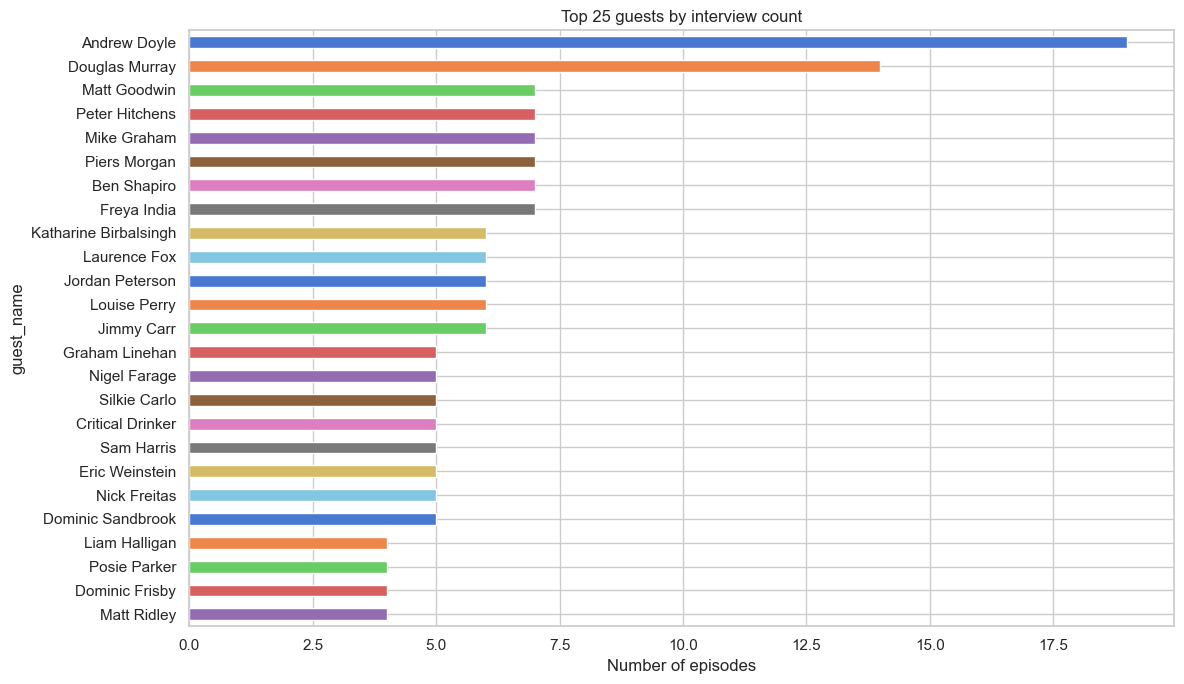

In [7]:
top_n = 25
top_guests = guest_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 7))
top_guests.plot.barh(ax=ax, color=sns.color_palette("muted", top_n))
ax.invert_yaxis()
ax.set_xlabel("Number of episodes")
ax.set_title(f"Top {top_n} guests by interview count")
plt.tight_layout()
plt.show()

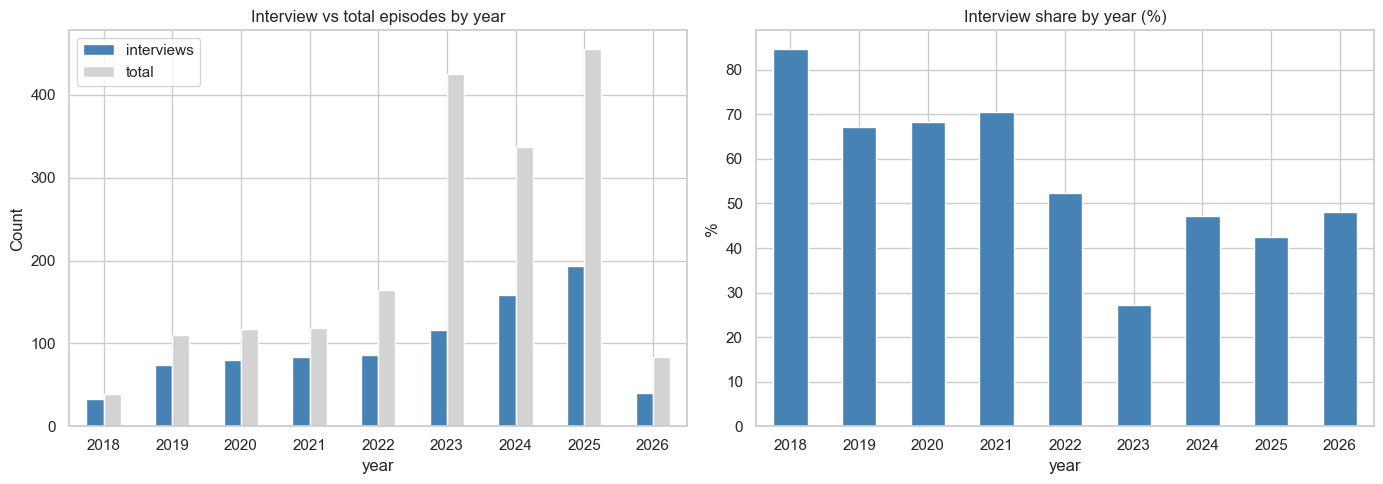

In [8]:
# Interviews over time
yearly = df.groupby("year")["is_interview"].agg(["sum", "count"])
yearly.columns = ["interviews", "total"]
yearly["pct"] = yearly["interviews"] / yearly["total"] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

yearly[["interviews", "total"]].plot.bar(ax=ax1, color=["steelblue", "lightgrey"])
ax1.set_title("Interview vs total episodes by year")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=0)

yearly["pct"].plot.bar(ax=ax2, color="steelblue")
ax2.set_title("Interview share by year (%)")
ax2.set_ylabel("%")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

---

## 3 — Political party affiliation

Curated dictionary of **formal** political affiliations — party membership, elected office, candidacy, or official party roles. Editorial leanings without formal ties are **not** included here (they are handled in §5 via topic analysis).

| Wing | Parties included |
|------|------------------|
| **right** | Conservative, Reform UK, Brexit Party, UKIP, Republican (US) |
| **left** | Labour, Green, Democrat (US), SNP |
| **centre** | Liberal Democrat |

In [9]:
# (party_name, wing, prominence)  —  wing ∈ {"right", "left"}
# Prominence scale:
#   5 = Leader (party leader, PM, presidential candidate)
#   4 = Cabinet (cabinet/shadow cabinet minister)
#   3 = Senior (MP, MEP, Lords, senior advisor)
#   2 = Junior (official candidate, party officer)
#   1 = Supporter (party member, public supporter)
PARTY_AFFILIATIONS: dict[str, tuple[str, str, int]] = {
    # ── UK: Conservative Party ───────────────────────────────────────
    "Kemi Badenoch":        ("Conservative", "right", 5),   # Party leader
    "Liz Truss":            ("Conservative", "right", 5),   # Former PM
    "Suella Braverman":     ("Conservative", "right", 4),   # Home Secretary
    "Sajid Javid":          ("Conservative", "right", 4),   # Chancellor / Home Sec
    "Michael Gove":         ("Conservative", "right", 4),   # Multiple cabinet roles
    "Priti Patel":          ("Conservative", "right", 4),   # Home Secretary
    "Dominic Raab":         ("Conservative", "right", 4),   # Foreign Sec / Deputy PM
    "Jacob Rees-Mogg":      ("Conservative", "right", 4),   # Leader of the House
    "Andrea Leadsom":       ("Conservative", "right", 4),   # Cabinet minister
    "David Davis":          ("Conservative", "right", 3),   # Former Brexit Sec, backbench
    "Steve Baker":          ("Conservative", "right", 3),   # MP, NI minister
    "Robert Jenrick":       ("Conservative → Reform UK", "right", 3),  # Immigration minister
    "Daniel Hannan":        ("Conservative", "right", 3),   # MEP, now Lord Hannan
    "Ann Widdecombe":       ("Conservative → Brexit Party", "right", 3),  # Former shadow cabinet
    "Steve Hilton":         ("Conservative", "right", 3),   # Director of Strategy under Cameron
    "Munira Mirza":         ("Conservative", "right", 3),   # Head of No 10 Policy Unit
    "Iain Dale":            ("Conservative", "right", 1),   # Former parliamentary candidate, broadcaster
    "Geoff Norcott":        ("Conservative", "right", 1),   # Party member, public supporter

    # ── UK: Reform UK / Brexit Party / UKIP ─────────────────────────
    "Nigel Farage":         ("Reform UK", "right", 5),      # Party leader
    "Richard Tice":         ("Reform UK", "right", 4),      # Party chairman → deputy leader
    "Claire Fox":           ("Brexit Party", "right", 3),   # MEP, now Baroness Fox
    "Ben Habib":            ("Reform UK", "right", 3),      # MEP, deputy leader
    "Laila Cunningham":     ("Reform UK", "right", 2),      # London mayoral candidate
    "Mahyar Tousi":         ("Reform UK", "right", 2),      # Candidate / activist

    # ── UK: Labour ───────────────────────────────────────────────────
    "Kate Hoey":            ("Labour", "left", 3),          # Former MP, minister

    # ── UK: Green / other left ───────────────────────────────────────
    "Peter Tatchell":       ("Green", "left", 1),           # Long-standing party member, activist

    # ── US: Republican ───────────────────────────────────────────────
    "Vivek Ramaswamy":      ("Republican", "right", 5),     # Presidential candidate
}

PROMINENCE_LABELS = {5: "Leader", 4: "Cabinet", 3: "Senior", 2: "Junior", 1: "Supporter"}

print(f"Affiliation dictionary: {len(PARTY_AFFILIATIONS)} entries")
print(f"  Right: {sum(1 for _, (_, w, _) in PARTY_AFFILIATIONS.items() if w == 'right')}")
print(f"  Left:  {sum(1 for _, (_, w, _) in PARTY_AFFILIATIONS.items() if w == 'left')}")
print(f"\nBy prominence tier:")
from collections import Counter as _Counter
for tier, count in sorted(_Counter(p for _, (_, _, p) in PARTY_AFFILIATIONS.items()).items(), reverse=True):
    print(f"  {tier} ({PROMINENCE_LABELS[tier]:10s}): {count}")


Affiliation dictionary: 27 entries
  Right: 25
  Left:  2

By prominence tier:
  5 (Leader    ): 4
  4 (Cabinet   ): 8
  3 (Senior    ): 10
  2 (Junior    ): 2
  1 (Supporter ): 3


In [10]:
def lookup_affiliation(name):
    if pd.isna(name):
        return pd.Series({"party": None, "affiliation_wing": None, "prominence": None})
    party, wing, prominence = PARTY_AFFILIATIONS.get(name, (None, None, None))
    return pd.Series({"party": party, "affiliation_wing": wing, "prominence": prominence})


df[["party", "affiliation_wing", "prominence"]] = df["guest_name"].apply(lookup_affiliation)

affiliated = df[df["party"].notna() & df["is_interview"]]
unaffiliated_interviews = df[df["party"].isna() & df["is_interview"]]

print(f"Interviews with party affiliation: {len(affiliated):,}")
print(f"Interviews without affiliation:    {len(unaffiliated_interviews):,}")
print(f"\n--- Affiliated guests matched ---")
aff_summary = (
    affiliated.groupby(["guest_name", "party", "affiliation_wing", "prominence"])
    .size()
    .reset_index(name="episodes")
    .sort_values(["prominence", "episodes"], ascending=[False, False])
)
aff_summary["prominence_label"] = aff_summary["prominence"].map(PROMINENCE_LABELS)
print(aff_summary.to_string(index=False))


Interviews with party affiliation: 31
Interviews without affiliation:    834

--- Affiliated guests matched ---
      guest_name                    party affiliation_wing  prominence  episodes prominence_label
    Nigel Farage                Reform UK            right         5.0         5           Leader
       Liz Truss             Conservative            right         5.0         2           Leader
   Kemi Badenoch             Conservative            right         5.0         1           Leader
 Vivek Ramaswamy               Republican            right         5.0         1           Leader
Suella Braverman             Conservative            right         4.0         1          Cabinet
    Steve Hilton             Conservative            right         3.0         3           Senior
  Robert Jenrick Conservative → Reform UK            right         3.0         2           Senior
      Claire Fox             Brexit Party            right         3.0         1           Senior
    Mu

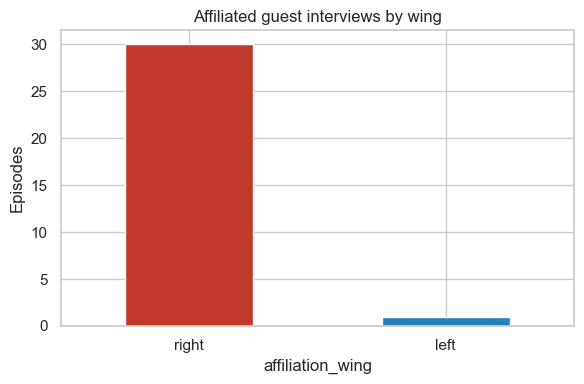

In [11]:
# Wing breakdown of affiliated interviews
wing_counts = affiliated["affiliation_wing"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"right": "#c0392b", "left": "#2980b9", "centre": "#f39c12"}
wing_counts.plot.bar(
    ax=ax,
    color=[colors.get(w, "grey") for w in wing_counts.index],
)
ax.set_title("Affiliated guest interviews by wing")
ax.set_ylabel("Episodes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

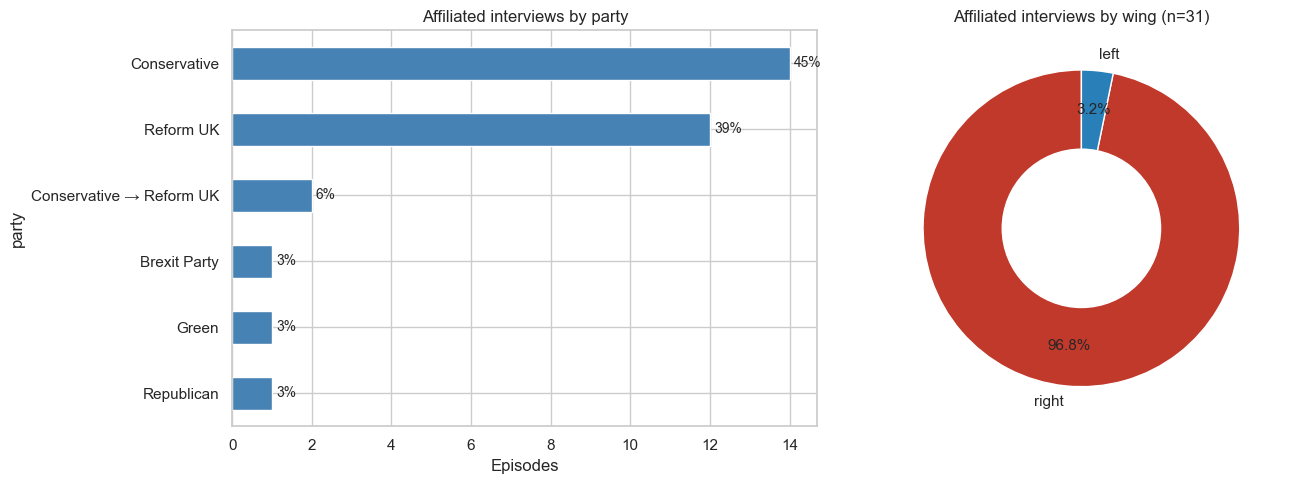

In [12]:
# Proportion of affiliated interviews by party
party_counts = affiliated.groupby("party").size().sort_values(ascending=False)
party_pct = (party_counts / party_counts.sum() * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# By party (count + %)
party_counts.plot.barh(ax=ax1, color="steelblue")
ax1.set_xlabel("Episodes")
ax1.set_title("Affiliated interviews by party")
ax1.invert_yaxis()
for bar, pct_val in zip(ax1.patches, party_pct.values):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{pct_val:.0f}%", va="center", fontsize=10)

# Wing as donut
wing_aff = affiliated["affiliation_wing"].value_counts()
w_colors = [colors.get(w, "grey") for w in wing_aff.index]
wedges, texts, autotexts = ax2.pie(
    wing_aff.values, labels=wing_aff.index, colors=w_colors,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75, textprops={"fontsize": 11},
)
centre = plt.Circle((0, 0), 0.50, fc="white")
ax2.add_artist(centre)
ax2.set_title(f"Affiliated interviews by wing (n={wing_aff.sum():,})")

plt.tight_layout()
plt.show()

---

## 4 — Interview stance: challenged vs endorsed

For guests with a political party affiliation, we classify whether the title/description framing **endorses** or **challenges** the guest's position.

Automated signals:
- **Endorsing keywords** in title — language that amplifies or validates the guest ("truth", "exposes", "reveals", "finally", "destroys", "must watch", "brilliant")
- **Challenging keywords** — language that questions or confronts ("wrong", "debate", "challenged", "confronted", "pushed back")
- **VADER sentiment** of title — positive compound scores tend to correlate with endorsement

Stance labels:
- **Unknown**: no endorsing or challenging keywords detected (insufficient signal).
- **Contested**: both endorsing and challenging keywords present in equal measure (genuinely ambiguous).
- **Endorsing** / **Challenging**: clear directional signal.

These are *indicators*, not definitive classifications. The `manual_review` column should be used for final judgement.


In [13]:
ENDORSING_TERMS = {
    "truth", "exposes", "reveals", "finally", "destroys", "must watch",
    "brilliant", "based", "truth bombs", "wake up", "brave", "honest",
    "incredible", "powerful", "important", "eye-opening", "eye opening",
    "nails it", "spot on", "genius", "legendary", "epic",
    "they don't want you", "they tried to cancel", "they can't cancel",
    "admitted it", "called it", "was right",
}

CHALLENGING_TERMS = {
    "wrong", "debate", "challenged", "confronted", "pushed back",
    "disagree", "heated", "grilled", "called out", "fact check",
    "debunked", "controversial", "clash",
}


def classify_stance(row):
    """
    Unknown   = no endorsing or challenging keywords found (no signal).
    Contested = both endorsing and challenging keywords found in equal measure.
    """
    title_lower = str(row["title"]).lower()
    desc_lower = str(row.get("description", "")).lower()[:500]  # first 500 chars
    text = title_lower + " " + desc_lower

    endorse_hits = sum(1 for t in ENDORSING_TERMS if t in text)
    challenge_hits = sum(1 for t in CHALLENGING_TERMS if t in text)

    if endorse_hits > challenge_hits:
        return "endorsing"
    if challenge_hits > endorse_hits:
        return "challenging"
    # Tied: discriminate unknown vs contested
    if endorse_hits > 0 and challenge_hits > 0:
        return "contested"
    return "unknown"


df["stance"] = df.apply(classify_stance, axis=1)

# Show stance breakdown for affiliated guests only
aff_stance = affiliated.copy()
aff_stance["stance"] = df.loc[aff_stance.index, "stance"]

print("Stance classification for affiliated guests:")
print(aff_stance["stance"].value_counts().to_string())
print(f"\n--- Detail ---")
for _, row in aff_stance.sort_values("published_date").iterrows():
    print(f"  [{row['stance']:11s}] {row['affiliation_wing']:5s}  {row['guest_name']:25s}  {row['title'][:70]}")


Stance classification for affiliated guests:
stance
unknown      25
endorsing     5
contested     1

--- Detail ---
  [unknown    ] left   Peter Tatchell             Peter Tatchell on Human Rights, Free Speech and Political Reform
  [contested  ] right  Claire Fox                 Claire Fox on Generation Snowflake, Free Speech and Debate
  [endorsing  ] right  Iain Dale                  Iain Dale on Conservatism, Immigration, Tax & the NHS
  [endorsing  ] right  Geoff Norcott              Geoff Norcott on Conservative Comedy, Brexit & Free Speech
  [unknown    ] right  Munira Mirza               Munira Mirza on Multiculturalism, "Institutional Racism", "White Privi
  [unknown    ] right  Geoff Norcott              Geoff Norcott: "Why I'm a Working Class Conservative"
  [unknown    ] right  Mahyar Tousi               Mahyar Tousi: "The BLM Agenda is Communist"
  [unknown    ] right  Iain Dale                  Why Can't We Just Get Along? - Iain Dale
  [unknown    ] right  Nigel Farage  

---

## 5 — Topic bias for non-affiliated guests

For interview episodes where the guest has **no formal party affiliation**, we assess:

1. Is the guest discussing a **right-coded** or **left-coded** topic?  
2. Is the treatment **sympathetic** to that topic or **critical** of the opposing position?

Topic coding uses the 13-category classification from notebook 03.  
Treatment uses a combination of title sentiment and framing-term matching.

In [14]:
# Topic → wing mapping
# Topics that are primarily discussed from a right-wing or left-wing frame
# in mainstream UK/US political discourse
TOPIC_WING = {
    # Right-coded: topics where the conservative/right position is the activist one
    "immigration_and_borders":      "right",
    "woke_and_cancel_culture":       "right",
    "free_speech_and_censorship":    "right",
    "islam_and_extremism":           "right",
    "trans_and_gender":              "right",
    "culture_war_general":           "right",

    # Left-coded: topics where the progressive/left position is the activist one
    "climate_and_environment":       "left",

    # Contested / cross-cutting: depend on framing
    "economy_and_cost_of_living":    "contested",
    "trump_and_us_politics":         "contested",
    "uk_politics":                   "contested",
    "russia_ukraine_geopolitics":    "contested",
    "israel_and_middle_east":        "contested",
}


def get_primary_topic_wing(topics_str):
    """Return the dominant topic wing from pipe-delimited topics string."""
    if pd.isna(topics_str) or topics_str == "":
        return "unknown"
    topics = [t.strip() for t in str(topics_str).split("|")]
    wings = [TOPIC_WING.get(t, "unknown") for t in topics]

    # Priority: if any topic is right- or left-coded, use that
    for w in ["right", "left"]:
        if w in wings:
            return w
    if "contested" in wings:
        return "contested"
    return "unknown"


df["topic_wing"] = df["topics"].apply(get_primary_topic_wing)

# Show breakdown for unaffiliated interviews
unaffiliated = df[df["party"].isna() & df["is_interview"]].copy()

print(f"Unaffiliated interviews: {len(unaffiliated):,}")
print(f"\nTopic wing breakdown:")
print(unaffiliated["topic_wing"].value_counts().to_string())

Unaffiliated interviews: 834

Topic wing breakdown:
topic_wing
right        340
unknown      292
contested    188
left          14


In [15]:
# Treatment classification: sympathetic vs critical
#
# Uses framing_score from notebook 03 and the updated framing_label
# to properly discriminate unknown / contested / neutral treatments.
#   framing_score > 0  → right-sympathetic framing
#   framing_score < 0  → left-sympathetic framing
#   framing_score == 0 → check framing_label for unknown / contested / neutral


def classify_treatment(row):
    """
    Classify how the topic is treated based on framing signals.

    Unknown   = no framing signal detected.
    Contested = framing terms present but direction ambiguous (Tier 2 ambiguous matches).
    Neutral   = balanced left/right framing terms (both sides, cancelled out).
    """
    topic_wing = row["topic_wing"]
    framing = row.get("framing_score", 0)
    fl = row.get("framing_label", "unknown")

    if topic_wing == "unknown":
        return "unknown"

    if topic_wing == "right":
        if framing > 0:
            return "sympathetic_to_right"
        elif framing < 0:
            return "critical_of_right"
        # framing == 0: propagate 3-way label
        if fl == "contested":
            return "contested"
        if fl == "neutral":
            return "neutral"
        return "unknown"

    if topic_wing == "left":
        if framing < 0:
            return "sympathetic_to_left"
        elif framing > 0:
            return "critical_of_left"
        if fl == "contested":
            return "contested"
        if fl == "neutral":
            return "neutral"
        return "unknown"

    if topic_wing == "contested":
        if framing > 0:
            return "right_framing"
        elif framing < 0:
            return "left_framing"
        if fl == "contested":
            return "contested"
        if fl == "neutral":
            return "neutral"
        return "unknown"

    return "unknown"


df["topic_treatment"] = df.apply(classify_treatment, axis=1)

print("Topic treatment for unaffiliated interviews:")
print(df.loc[unaffiliated.index, "topic_treatment"].value_counts().to_string())


Topic treatment for unaffiliated interviews:
topic_treatment
unknown                 773
sympathetic_to_right     56
contested                 4
right_framing             1


In [16]:
# Crosstab: topic wing × treatment
ct = pd.crosstab(
    df.loc[unaffiliated.index, "topic_wing"],
    df.loc[unaffiliated.index, "topic_treatment"],
)
print("Topic wing × treatment crosstab (unaffiliated interviews):")
print(ct.to_string())

Topic wing × treatment crosstab (unaffiliated interviews):
topic_treatment  contested  right_framing  sympathetic_to_right  unknown
topic_wing                                                              
contested                0              1                     0      187
left                     0              0                     0       14
right                    4              0                    56      280
unknown                  0              0                     0      292


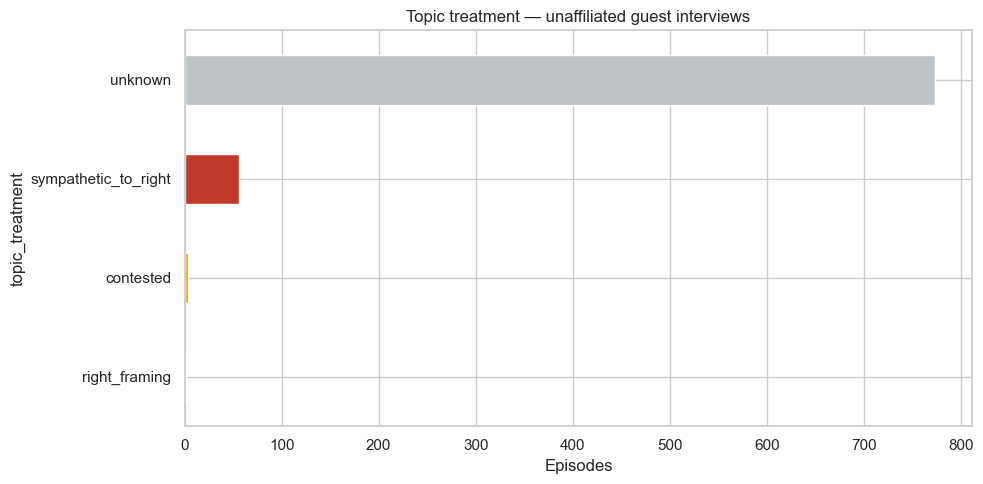

In [17]:
# Visualise topic treatment distribution
treat_counts = df.loc[unaffiliated.index, "topic_treatment"].value_counts()

treat_colors = {
    "sympathetic_to_right": "#c0392b",
    "critical_of_left":    "#e74c3c",
    "right_framing":       "#d4837a",
    "contested":           "#F59E0B",
    "neutral":             "#95a5a6",
    "unknown":             "#bdc3c7",
    "left_framing":        "#7fb3d3",
    "sympathetic_to_left": "#2980b9",
    "critical_of_right":   "#3498db",
}

fig, ax = plt.subplots(figsize=(10, 5))
treat_counts.plot.barh(
    ax=ax,
    color=[treat_colors.get(t, "grey") for t in treat_counts.index],
)
ax.set_xlabel("Episodes")
ax.set_title("Topic treatment — unaffiliated guest interviews")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


---

## 6 — Combined bias category & CSV export

Each interview episode gets a single `bias_category` label summarising the analysis:

| Category | Meaning |
|---|---|
| `right_affiliated_endorsed` | Guest has right-wing party affiliation, endorsing framing |
| `right_affiliated_challenged` | Guest has right-wing party affiliation, challenging framing |
| `right_affiliated_contested` | Guest has right-wing party affiliation, mixed endorsing/challenging signals |
| `right_affiliated_unknown` | Guest has right-wing party affiliation, no stance signal |
| `left_affiliated_endorsed` | Guest has left-wing party affiliation, endorsing framing |
| `left_affiliated_challenged` | Guest has left-wing party affiliation, challenging framing |
| `left_affiliated_contested` | Guest has left-wing party affiliation, mixed endorsing/challenging signals |
| `left_affiliated_unknown` | Guest has left-wing party affiliation, no stance signal |
| `right_topic_sympathetic` | No affiliation; right-coded topic, sympathetic treatment |
| `right_topic_critical` | No affiliation; right-coded topic, critical treatment |
| `right_topic_contested` | No affiliation; right-coded topic, contested framing |
| `right_topic_neutral` | No affiliation; right-coded topic, balanced framing |
| `left_topic_sympathetic` | No affiliation; left-coded topic, sympathetic treatment |
| `left_topic_critical` | No affiliation; left-coded topic, critical treatment |
| `contested_right_framing` | No affiliation; contested topic, right-leaning framing |
| `contested_left_framing` | No affiliation; contested topic, left-leaning framing |
| `contested_topic_contested` | No affiliation; contested topic, ambiguous framing |
| `contested_topic_neutral` | No affiliation; contested topic, balanced framing |
| `unclassified` | Insufficient signal for automated classification |


In [18]:
def assign_bias_category(row):
    if not row["is_interview"]:
        return None  # not an interview

    # --- Affiliated guest ---
    if pd.notna(row["party"]):
        wing = row["affiliation_wing"]
        stance = row["stance"]
        return f"{wing}_affiliated_{stance}"

    # --- Unaffiliated guest: topic-based ---
    tw = row["topic_wing"]
    tt = row["topic_treatment"]

    if tw == "right":
        if tt == "sympathetic_to_right":
            return "right_topic_sympathetic"
        elif tt == "critical_of_right":
            return "right_topic_critical"
        elif tt == "contested":
            return "right_topic_contested"
        elif tt == "neutral":
            return "right_topic_neutral"
    elif tw == "left":
        if tt == "sympathetic_to_left":
            return "left_topic_sympathetic"
        elif tt == "critical_of_left":
            return "left_topic_critical"
        elif tt == "contested":
            return "left_topic_contested"
        elif tt == "neutral":
            return "left_topic_neutral"
    elif tw == "contested":
        if tt == "right_framing":
            return "contested_right_framing"
        elif tt == "left_framing":
            return "contested_left_framing"
        elif tt == "contested":
            return "contested_topic_contested"
        elif tt == "neutral":
            return "contested_topic_neutral"

    return "unclassified"


df["bias_category"] = df.apply(assign_bias_category, axis=1)

interviews_final = df[df["is_interview"]].copy()
print(f"Bias category breakdown ({len(interviews_final):,} interviews):\n")
print(interviews_final["bias_category"].value_counts().to_string())


Bias category breakdown (865 interviews):

bias_category
unclassified                  773
right_topic_sympathetic        56
right_affiliated_unknown       24
right_affiliated_endorsing      5
right_topic_contested           4
left_affiliated_unknown         1
right_affiliated_contested      1
contested_right_framing         1


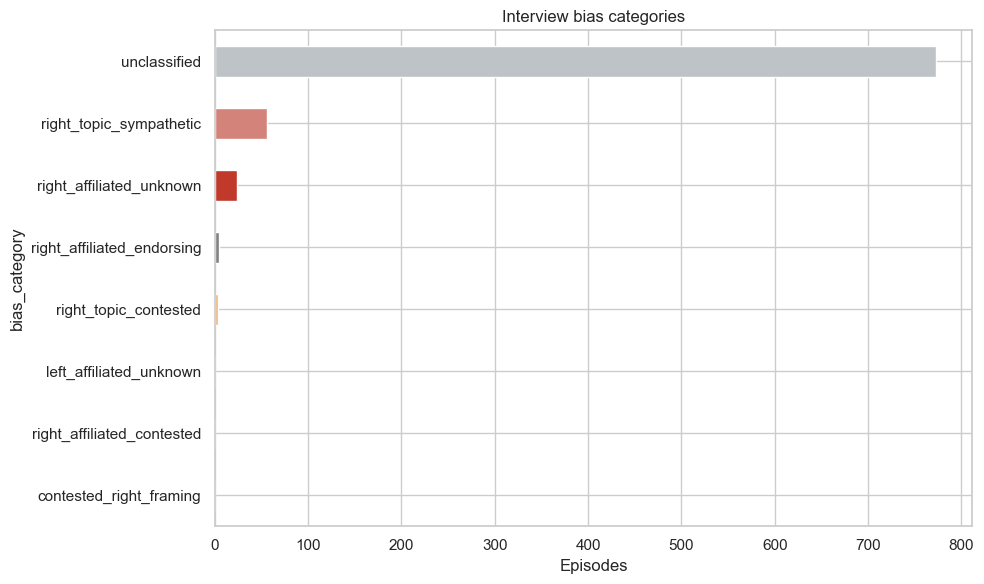

In [19]:
# Visualise bias categories
cat_counts = interviews_final["bias_category"].value_counts()

cat_colors = {
    "right_affiliated_endorsed":    "#922b21",
    "right_affiliated_unknown":     "#c0392b",
    "right_affiliated_contested":   "#d98880",
    "right_affiliated_challenging": "#e6b0aa",
    "right_topic_sympathetic":      "#d4837a",
    "right_topic_critical":         "#f5b7b1",
    "right_topic_contested":        "#f0b27a",
    "right_topic_neutral":          "#fad7a0",
    "contested_right_framing":      "#edbb99",
    "contested_topic_contested":    "#F59E0B",
    "contested_topic_neutral":      "#f9e79f",
    "contested_left_framing":       "#aed6f1",
    "left_topic_sympathetic":       "#7fb3d3",
    "left_topic_critical":          "#5499c7",
    "left_topic_contested":         "#85c1e9",
    "left_topic_neutral":           "#aed6f1",
    "left_affiliated_endorsed":     "#2471a3",
    "left_affiliated_unknown":      "#2980b9",
    "left_affiliated_contested":    "#7fb3d3",
    "left_affiliated_challenging":  "#a9cce3",
    "unclassified":                 "#bdc3c7",
}

fig, ax = plt.subplots(figsize=(10, 6))
cat_counts.plot.barh(
    ax=ax,
    color=[cat_colors.get(c, "grey") for c in cat_counts.index],
)
ax.set_xlabel("Episodes")
ax.set_title("Interview bias categories")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


---

## 6b — Proportion analysis

The charts above show raw episode counts. The following views show **proportions** — what share of interviews, guests, and yearly output each bias signal represents.

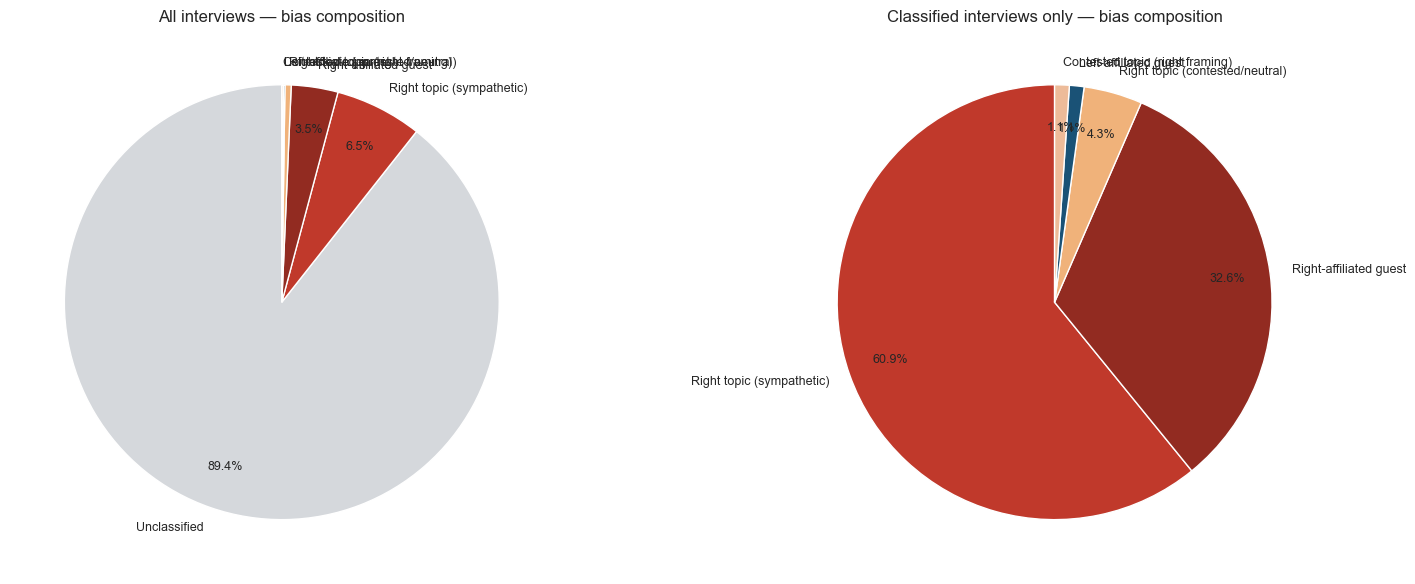


Classified: 92 episodes  |  Unclassified: 773 episodes


In [20]:
# --- 1. Overall interview composition (all interviews) ---
# Group bias categories into broader buckets for a readable pie chart

def broad_bucket(cat):
    if pd.isna(cat):
        return None
    if "right_affiliated" in cat:
        return "Right-affiliated guest"
    if "left_affiliated" in cat:
        return "Left-affiliated guest"
    if cat == "right_topic_sympathetic":
        return "Right topic (sympathetic)"
    if cat == "right_topic_critical":
        return "Right topic (critical)"
    if cat in ("right_topic_contested", "right_topic_neutral"):
        return "Right topic (contested/neutral)"
    if cat == "left_topic_sympathetic":
        return "Left topic (sympathetic)"
    if cat == "left_topic_critical":
        return "Left topic (critical)"
    if cat in ("left_topic_contested", "left_topic_neutral"):
        return "Left topic (contested/neutral)"
    if "contested_right" in cat:
        return "Contested topic (right framing)"
    if "contested_left" in cat:
        return "Contested topic (left framing)"
    if cat in ("contested_topic_contested", "contested_topic_neutral"):
        return "Contested topic (contested/neutral)"
    return "Unclassified"

interviews_final["broad_bias"] = interviews_final["bias_category"].apply(broad_bucket)
bucket_counts = interviews_final["broad_bias"].value_counts()

bucket_colors = {
    "Right-affiliated guest":              "#922b21",
    "Right topic (sympathetic)":           "#c0392b",
    "Right topic (critical)":              "#f5b7b1",
    "Right topic (contested/neutral)":     "#f0b27a",
    "Contested topic (right framing)":     "#edbb99",
    "Contested topic (contested/neutral)": "#F59E0B",
    "Contested topic (left framing)":      "#aed6f1",
    "Left topic (sympathetic)":            "#2980b9",
    "Left topic (critical)":               "#5499c7",
    "Left topic (contested/neutral)":      "#85c1e9",
    "Left-affiliated guest":               "#1a5276",
    "Unclassified":                        "#d5d8dc",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie — all interviews
ax1.pie(
    bucket_counts.values,
    labels=bucket_counts.index,
    colors=[bucket_colors.get(b, "grey") for b in bucket_counts.index],
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 9},
)
ax1.set_title("All interviews — bias composition", fontsize=12)

# Pie — classified only (exclude unclassified)
classified = bucket_counts.drop("Unclassified", errors="ignore")
ax2.pie(
    classified.values,
    labels=classified.index,
    colors=[bucket_colors.get(b, "grey") for b in classified.index],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 9},
)
ax2.set_title("Classified interviews only — bias composition", fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nClassified: {classified.sum():,} episodes  |  Unclassified: {bucket_counts.get('Unclassified', 0):,} episodes")


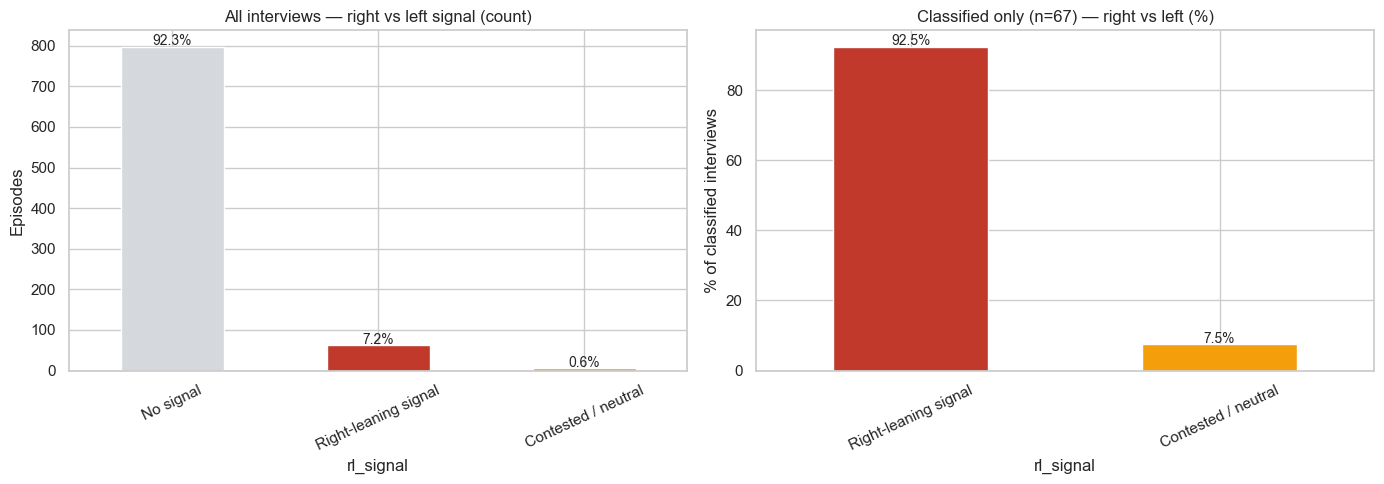

In [21]:
# --- 2. Right vs left signal — simplified proportion ---
# Collapse all categories into right-leaning / left-leaning / contested / unknown

def right_left_signal(cat):
    if pd.isna(cat):
        return None
    if any(k in cat for k in ["right_affiliated_endorsing", "right_topic_sympathetic", "contested_right"]):
        return "Right-leaning signal"
    if any(k in cat for k in ["left_affiliated_endorsing", "left_topic_sympathetic", "contested_left"]):
        return "Left-leaning signal"
    if any(k in cat for k in ["right_topic_critical", "left_topic_critical",
                               "right_affiliated_challenging", "left_affiliated_challenging"]):
        return "Cross-cutting"
    if any(k in cat for k in ["_contested", "_neutral"]):
        return "Contested / neutral"
    return "No signal"

interviews_final["rl_signal"] = interviews_final["bias_category"].apply(right_left_signal)
rl_counts = interviews_final["rl_signal"].value_counts()

rl_colors = {
    "Right-leaning signal": "#c0392b",
    "Left-leaning signal":  "#2980b9",
    "Cross-cutting":        "#f39c12",
    "Contested / neutral":  "#F59E0B",
    "No signal":            "#d5d8dc",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# All interviews
rl_counts.plot.bar(
    ax=ax1,
    color=[rl_colors.get(c, "grey") for c in rl_counts.index],
)
ax1.set_title("All interviews — right vs left signal (count)")
ax1.set_ylabel("Episodes")
ax1.tick_params(axis="x", rotation=25)

# Percentage labels on bars
for bar in ax1.patches:
    h = bar.get_height()
    pct = h / len(interviews_final) * 100
    ax1.text(bar.get_x() + bar.get_width() / 2, h + 3, f"{pct:.1f}%",
             ha="center", fontsize=10)

# Classified only (exclude "No signal")
rl_classified = rl_counts.drop("No signal", errors="ignore")
total_classified = rl_classified.sum()
rl_pct = (rl_classified / total_classified * 100).round(1)

rl_pct.plot.bar(
    ax=ax2,
    color=[rl_colors.get(c, "grey") for c in rl_pct.index],
)
ax2.set_title(f"Classified only (n={total_classified:,}) — right vs left (%)")
ax2.set_ylabel("% of classified interviews")
ax2.tick_params(axis="x", rotation=25)

for bar, pct_val in zip(ax2.patches, rl_pct.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{pct_val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


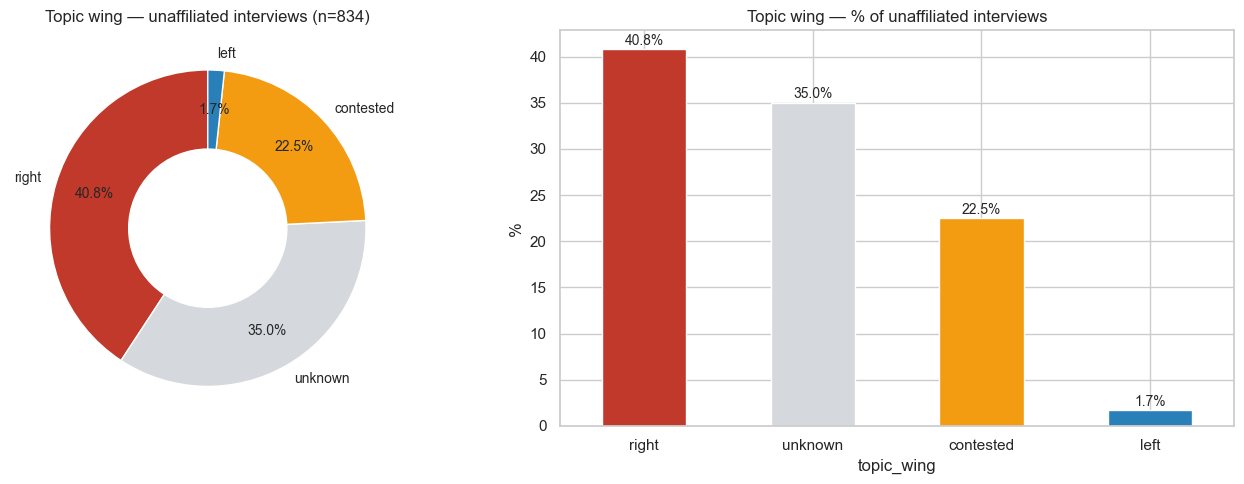

In [22]:
# --- 3. Topic wing proportions for unaffiliated guest interviews ---

unaff_topic = df.loc[unaffiliated.index, "topic_wing"].value_counts()
unaff_topic_pct = (unaff_topic / unaff_topic.sum() * 100).round(1)

wing_colors = {
    "right": "#c0392b", "left": "#2980b9",
    "contested": "#f39c12", "unknown": "#d5d8dc",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart
wedges, texts, autotexts = ax1.pie(
    unaff_topic.values,
    labels=unaff_topic.index,
    colors=[wing_colors.get(w, "grey") for w in unaff_topic.index],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 10},
)
centre_circle = plt.Circle((0, 0), 0.50, fc="white")
ax1.add_artist(centre_circle)
ax1.set_title(f"Topic wing — unaffiliated interviews (n={unaff_topic.sum():,})")

# Bar with % labels
unaff_topic_pct.plot.bar(
    ax=ax2,
    color=[wing_colors.get(w, "grey") for w in unaff_topic_pct.index],
)
ax2.set_title("Topic wing — % of unaffiliated interviews")
ax2.set_ylabel("%")
ax2.tick_params(axis="x", rotation=0)
for bar, pct_val in zip(ax2.patches, unaff_topic_pct.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{pct_val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

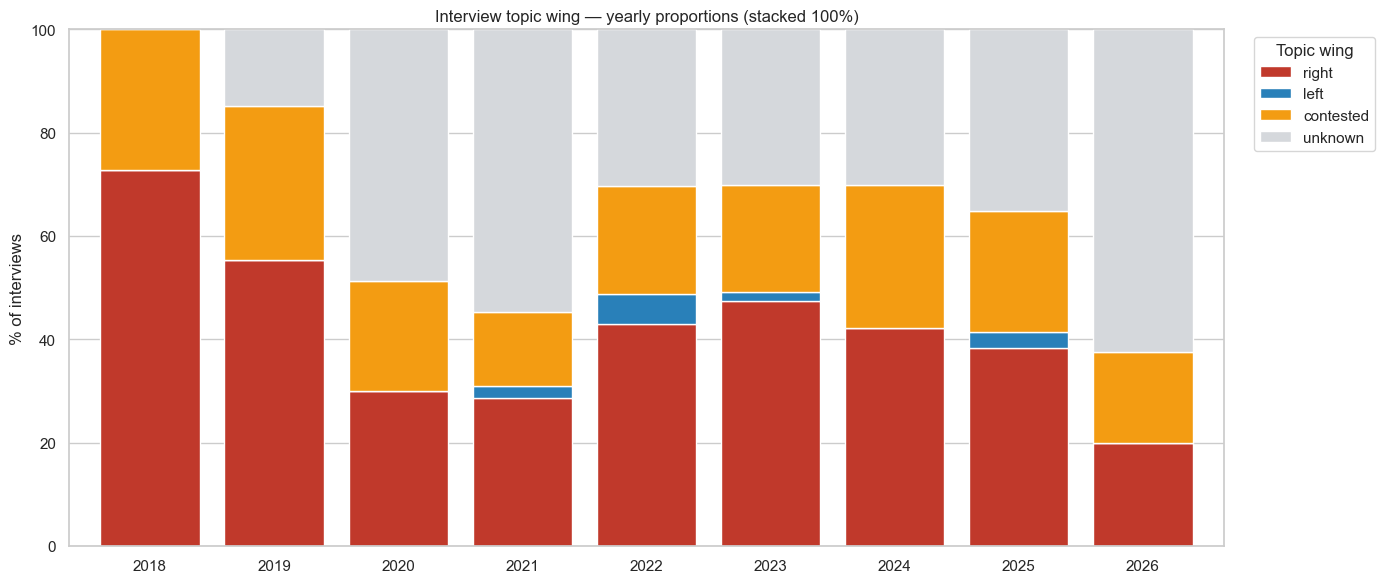

In [23]:
# --- 4. Topic wing proportions over time (stacked 100% bar) ---

interviews_with_year = interviews_final.copy()
interviews_with_year["topic_wing"] = df.loc[interviews_with_year.index, "topic_wing"]

yearly_wings = pd.crosstab(
    interviews_with_year["year"],
    interviews_with_year["topic_wing"],
    normalize="index",
) * 100

# Reorder columns for consistent stacking
col_order = [c for c in ["right", "left", "contested", "unknown"] if c in yearly_wings.columns]
yearly_wings = yearly_wings[col_order]

wing_colors_list = [wing_colors.get(c, "grey") for c in col_order]

fig, ax = plt.subplots(figsize=(14, 6))
yearly_wings.plot.bar(
    stacked=True, ax=ax, color=wing_colors_list, width=0.8, edgecolor="white",
)
ax.set_title("Interview topic wing — yearly proportions (stacked 100%)")
ax.set_ylabel("% of interviews")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Topic wing", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

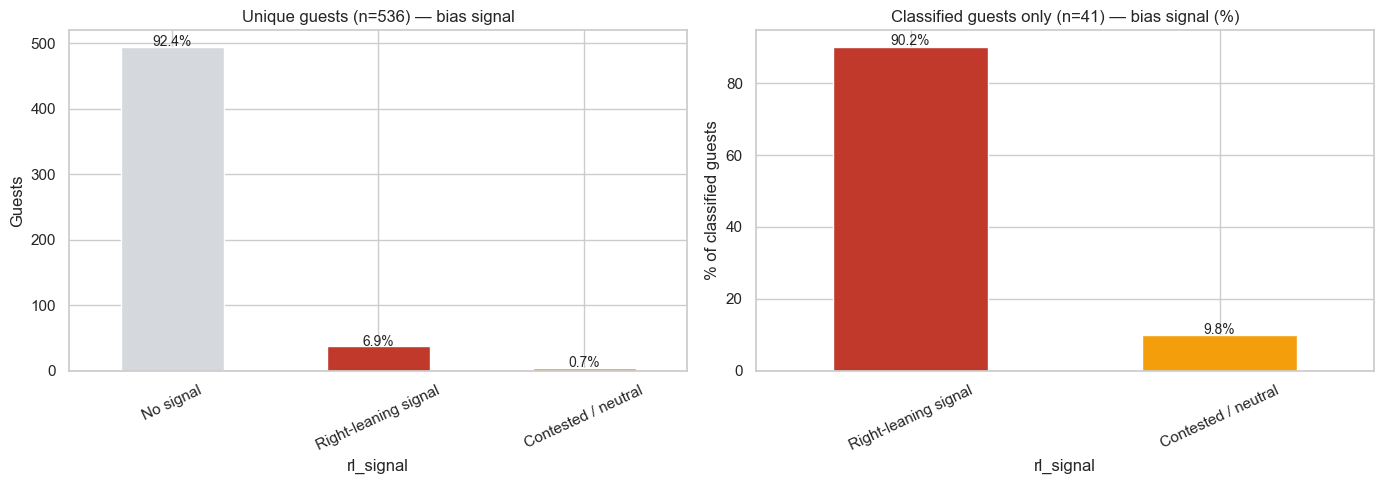


Unique guests with right-leaning signal: 37
Unique guests with left-leaning signal:  0
Unique guests unclassified:              495


In [24]:
# --- 5. Unique guest proportions (avoids repeat-guest inflation) ---
# For each unique guest, assign their dominant bias signal across all appearances

guest_bias = (
    interviews_final.groupby("guest_name")["bias_category"]
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unclassified")
    .reset_index(name="dominant_bias")
)
guest_bias["rl_signal"] = guest_bias["dominant_bias"].apply(right_left_signal)

guest_rl_counts = guest_bias["rl_signal"].value_counts()
guest_rl_pct = (guest_rl_counts / guest_rl_counts.sum() * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# All unique guests
guest_rl_counts.plot.bar(
    ax=ax1,
    color=[rl_colors.get(c, "grey") for c in guest_rl_counts.index],
)
ax1.set_title(f"Unique guests (n={len(guest_bias):,}) — bias signal")
ax1.set_ylabel("Guests")
ax1.tick_params(axis="x", rotation=25)
for bar in ax1.patches:
    h = bar.get_height()
    pct = h / len(guest_bias) * 100
    ax1.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{pct:.1f}%",
             ha="center", fontsize=10)

# Classified unique guests only
guest_classified = guest_rl_counts.drop("No signal", errors="ignore")
guest_classified_pct = (guest_classified / guest_classified.sum() * 100).round(1)

guest_classified_pct.plot.bar(
    ax=ax2,
    color=[rl_colors.get(c, "grey") for c in guest_classified_pct.index],
)
ax2.set_title(f"Classified guests only (n={guest_classified.sum():,}) — bias signal (%)")
ax2.set_ylabel("% of classified guests")
ax2.tick_params(axis="x", rotation=25)
for bar, pct_val in zip(ax2.patches, guest_classified_pct.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{pct_val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nUnique guests with right-leaning signal: {guest_rl_counts.get('Right-leaning signal', 0):,}")
print(f"Unique guests with left-leaning signal:  {guest_rl_counts.get('Left-leaning signal', 0):,}")
print(f"Unique guests unclassified:              {guest_rl_counts.get('No signal', 0):,}")

---

## 7 — Guest Prominence & Influence

Two complementary metrics:

1. **Prominence tier** (affiliated guests only) — formal political rank (Leader → Supporter) manually assigned from public record.
2. **Guest influence** (all guests) — data-driven metric using median view count across a guest's episodes as a proxy for audience pull.

These allow us to weight bias signals: an endorsing interview with a party *leader* carries more political signal than one with a party *supporter*.


In [25]:
# --- Compute data-driven guest influence metrics (all guests) ---
guest_stats = (
    interviews_final
    .groupby("guest_name")
    .agg(
        guest_episodes=("view_count", "size"),
        guest_median_views=("view_count", "median"),
        guest_total_views=("view_count", "sum"),
    )
    .reset_index()
)

# Percentile-based influence tier
p90 = guest_stats["guest_median_views"].quantile(0.90)
p60 = guest_stats["guest_median_views"].quantile(0.60)

def influence_tier(median_views):
    if median_views >= p90:
        return "high"
    elif median_views >= p60:
        return "medium"
    return "low"

guest_stats["guest_influence_tier"] = guest_stats["guest_median_views"].apply(influence_tier)

# Merge back into interviews dataframe
interviews_final = interviews_final.merge(
    guest_stats[["guest_name", "guest_episodes", "guest_median_views", "guest_influence_tier"]],
    on="guest_name", how="left",
)
# Also merge into main df for downstream use
df = df.merge(
    guest_stats[["guest_name", "guest_episodes", "guest_median_views", "guest_influence_tier"]],
    on="guest_name", how="left",
)

print(f"Guest influence tiers (n={len(guest_stats):,} unique guests):")
print(guest_stats["guest_influence_tier"].value_counts().to_string())
print(f"\nThresholds: high ≥ {p90:,.0f} views  |  medium ≥ {p60:,.0f} views")
print(f"\nTop 10 by median views:")
print(guest_stats.nlargest(10, "guest_median_views")[
    ["guest_name", "guest_episodes", "guest_median_views", "guest_influence_tier"]
].to_string(index=False))


Guest influence tiers (n=536 unique guests):
guest_influence_tier
low       321
medium    161
high       54

Thresholds: high ≥ 515,408 views  |  medium ≥ 142,443 views

Top 10 by median views:
           guest_name  guest_episodes  guest_median_views guest_influence_tier
          JRE Podcast               1           5999262.0                 high
                Nazis               1           2662943.0                 high
    Joe Rogan Podcast               1           2268566.0                 high
    Identity Politics               1           1704377.0                 high
Uncle Roger INTERVIEW               1           1538707.0                 high
         Roland Fryer               1           1335045.0                 high
     Tony Hinchcliffe               2           1292278.0                 high
        Rob Schneider               2           1275972.5                 high
         VIRAL SPEECH               1           1191385.0                 high
           Bill 

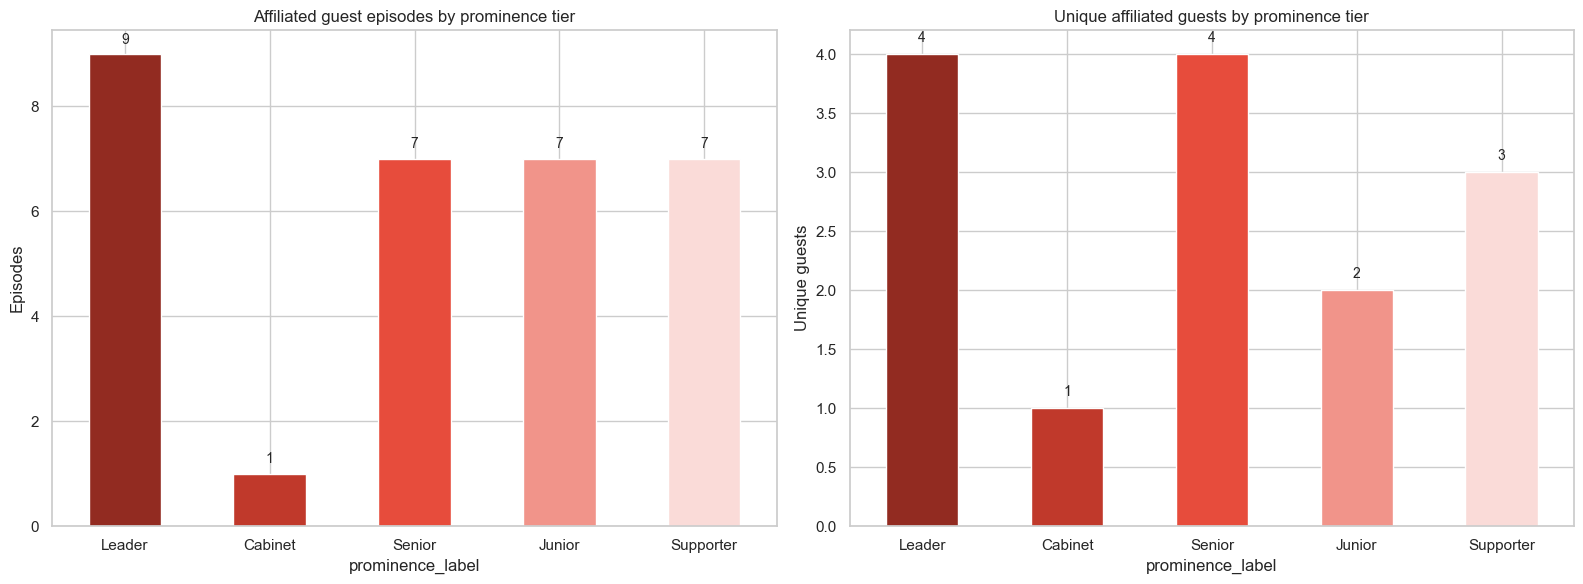

In [26]:
# --- Prominence tier breakdown (affiliated guests) ---
aff_with_prominence = affiliated.copy()
aff_with_prominence["prominence"] = df.loc[aff_with_prominence.index, "prominence"]
aff_with_prominence["prominence_label"] = aff_with_prominence["prominence"].map(PROMINENCE_LABELS)
aff_with_prominence["stance"] = df.loc[aff_with_prominence.index, "stance"]

tier_order = ["Leader", "Cabinet", "Senior", "Junior", "Supporter"]
tier_colors = {"Leader": "#922b21", "Cabinet": "#c0392b", "Senior": "#e74c3c",
               "Junior": "#f1948a", "Supporter": "#fadbd8"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar: episodes per prominence tier
tier_counts = (
    aff_with_prominence["prominence_label"]
    .value_counts()
    .reindex(tier_order, fill_value=0)
)
tier_counts.plot.bar(
    ax=ax1,
    color=[tier_colors.get(t, "grey") for t in tier_counts.index],
)
ax1.set_title("Affiliated guest episodes by prominence tier")
ax1.set_ylabel("Episodes")
ax1.tick_params(axis="x", rotation=0)
for bar in ax1.patches:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.2, f"{int(h)}",
                 ha="center", fontsize=10)

# Unique guests per tier
unique_per_tier = (
    aff_with_prominence.groupby("prominence_label")["guest_name"]
    .nunique()
    .reindex(tier_order, fill_value=0)
)
unique_per_tier.plot.bar(
    ax=ax2,
    color=[tier_colors.get(t, "grey") for t in unique_per_tier.index],
)
ax2.set_title("Unique affiliated guests by prominence tier")
ax2.set_ylabel("Unique guests")
ax2.tick_params(axis="x", rotation=0)
for bar in ax2.patches:
    h = bar.get_height()
    if h > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{int(h)}",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.show()


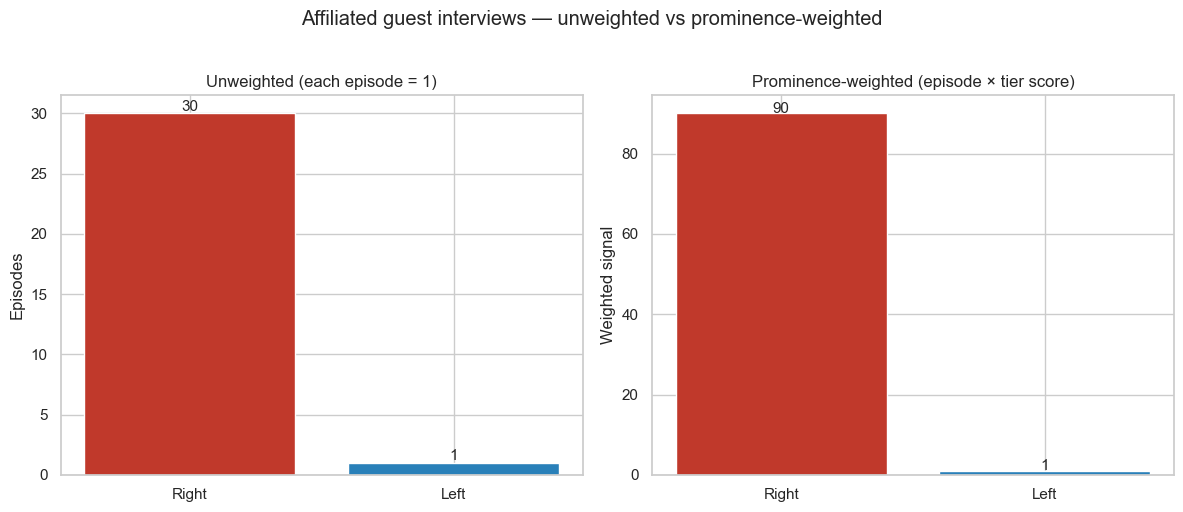

Unweighted ratio:  Right 30 : Left 1  (96.8% right)
Weighted ratio:    Right 90 : Left 1  (98.9% right)


In [27]:
# --- Weighted vs unweighted bias signal (affiliated guests) ---
# Unweighted: each episode counts as 1
# Weighted: each episode counts as its guest's prominence score

aff_for_weight = affiliated.copy()
aff_for_weight["prominence"] = df.loc[aff_for_weight.index, "prominence"].astype(float)
aff_for_weight["wing"] = df.loc[aff_for_weight.index, "affiliation_wing"]

# Unweighted counts
right_unwt = (aff_for_weight["wing"] == "right").sum()
left_unwt = (aff_for_weight["wing"] == "left").sum()

# Prominence-weighted counts
right_wt = aff_for_weight.loc[aff_for_weight["wing"] == "right", "prominence"].sum()
left_wt = aff_for_weight.loc[aff_for_weight["wing"] == "left", "prominence"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Unweighted
ax1.bar(["Right", "Left"], [right_unwt, left_unwt], color=["#c0392b", "#2980b9"])
ax1.set_title("Unweighted (each episode = 1)")
ax1.set_ylabel("Episodes")
for bar in ax1.patches:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.2, f"{int(h)}",
             ha="center", fontsize=11)

# Prominence-weighted
ax2.bar(["Right", "Left"], [right_wt, left_wt], color=["#c0392b", "#2980b9"])
ax2.set_title("Prominence-weighted (episode × tier score)")
ax2.set_ylabel("Weighted signal")
for bar in ax2.patches:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.2, f"{h:.0f}",
             ha="center", fontsize=11)

plt.suptitle("Affiliated guest interviews — unweighted vs prominence-weighted", y=1.02)
plt.tight_layout()
plt.show()

print(f"Unweighted ratio:  Right {right_unwt} : Left {left_unwt}  ({right_unwt/(right_unwt+left_unwt)*100:.1f}% right)")
print(f"Weighted ratio:    Right {right_wt:.0f} : Left {left_wt:.0f}  ({right_wt/(right_wt+left_wt)*100:.1f}% right)")


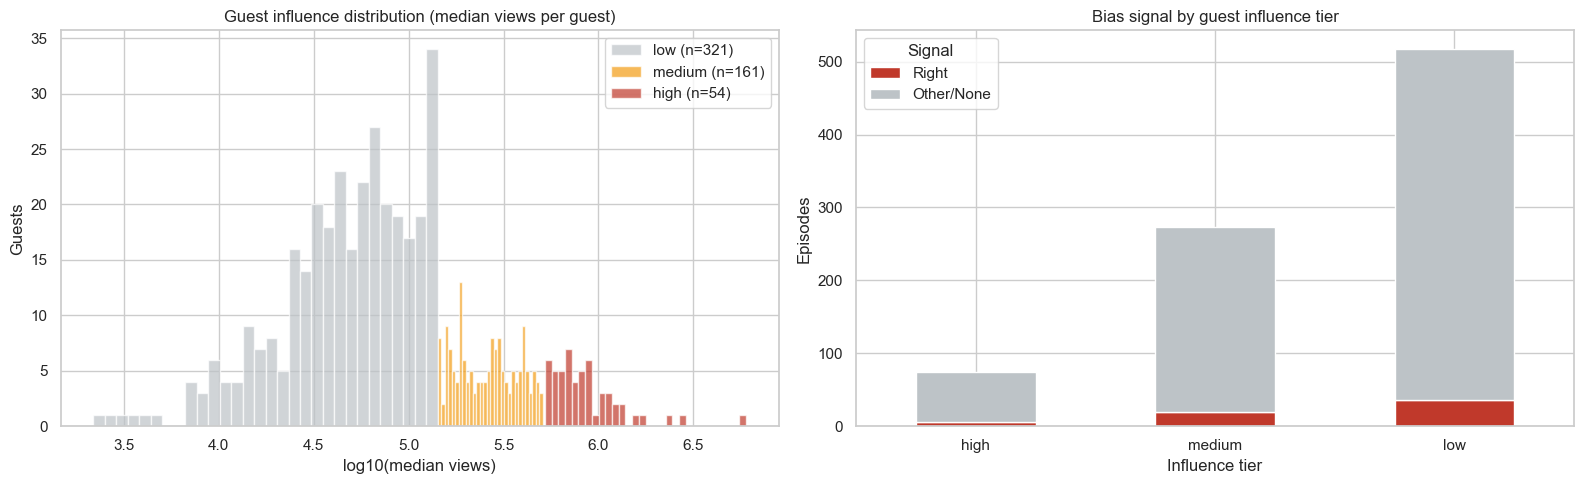

Top 20 most influential guests (by median views):
                        guest_name  guest_episodes  guest_median_views guest_influence_tier prominence_label           dominant_bias
                       JRE Podcast               1           5999262.0                 high                —            unclassified
                             Nazis               1           2662943.0                 high                —            unclassified
                 Joe Rogan Podcast               1           2268566.0                 high                —            unclassified
                 Identity Politics               1           1704377.0                 high                — right_topic_sympathetic
             Uncle Roger INTERVIEW               1           1538707.0                 high                —            unclassified
                      Roland Fryer               1           1335045.0                 high                —            unclassified
                  T

In [28]:
# --- Guest influence: distribution + top-20 table ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of median views per guest
tier_hist_colors = {"high": "#c0392b", "medium": "#f39c12", "low": "#bdc3c7"}
for tier in ["low", "medium", "high"]:
    subset = guest_stats[guest_stats["guest_influence_tier"] == tier]
    ax1.hist(
        np.log10(subset["guest_median_views"].clip(lower=1)),
        bins=30, alpha=0.7,
        color=tier_hist_colors[tier], label=f"{tier} (n={len(subset)})",
    )
ax1.set_xlabel("log10(median views)")
ax1.set_ylabel("Guests")
ax1.set_title("Guest influence distribution (median views per guest)")
ax1.legend()

# Influence tier by bias signal
int_with_tier = interviews_final.copy()

def simple_signal(cat):
    if pd.isna(cat):
        return "No signal"
    if any(k in cat for k in ["right_affiliated_endorsing", "right_topic_sympathetic", "contested_right"]):
        return "Right"
    if any(k in cat for k in ["left_affiliated_endorsing", "left_topic_sympathetic", "contested_left"]):
        return "Left"
    return "Other/None"

int_with_tier["simple_signal"] = int_with_tier["bias_category"].apply(simple_signal)

ct_inf = pd.crosstab(
    int_with_tier["guest_influence_tier"],
    int_with_tier["simple_signal"],
)
tier_order_inf = [t for t in ["high", "medium", "low"] if t in ct_inf.index]
sig_colors = {"Right": "#c0392b", "Left": "#2980b9", "Other/None": "#bdc3c7"}
sig_order = [c for c in ["Right", "Left", "Other/None"] if c in ct_inf.columns]
ct_inf.loc[tier_order_inf, sig_order].plot.bar(
    stacked=True, ax=ax2,
    color=[sig_colors[c] for c in sig_order],
)
ax2.set_title("Bias signal by guest influence tier")
ax2.set_ylabel("Episodes")
ax2.set_xlabel("Influence tier")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(title="Signal")

plt.tight_layout()
plt.show()

# Top-20 most influential guests
top20 = guest_stats.nlargest(20, "guest_median_views").copy()
# Merge bias category (mode across appearances)
guest_dom_bias = (
    interviews_final.groupby("guest_name")["bias_category"]
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unclassified")
    .reset_index(name="dominant_bias")
)
top20 = top20.merge(guest_dom_bias, on="guest_name", how="left")
# Merge prominence (for affiliated)
prom_lookup = pd.DataFrame([
    {"guest_name": k, "prominence": v[2], "prominence_label": PROMINENCE_LABELS[v[2]]}
    for k, v in PARTY_AFFILIATIONS.items()
])
top20 = top20.merge(prom_lookup, on="guest_name", how="left")
top20["prominence_label"] = top20["prominence_label"].fillna("—")

print("Top 20 most influential guests (by median views):")
print(
    top20[[
        "guest_name", "guest_episodes", "guest_median_views",
        "guest_influence_tier", "prominence_label", "dominant_bias",
    ]].to_string(index=False)
)


In [29]:
# Build export dataframe — interviews only
EXPORT_COLS = [
    "published_date", "type", "title", "url",
    "view_count", "like_count", "comment_count",
    "guest_name", "party", "affiliation_wing", "prominence",
    "topics", "topic_wing", "topic_treatment",
    "stance", "bias_category",
    "framing_score", "vader_title", "vader_desc", "vader_composite",
    "guest_episodes", "guest_median_views", "guest_influence_tier",
]

export_df = interviews_final[EXPORT_COLS].copy()
export_df["prominence_label"] = export_df["prominence"].map(PROMINENCE_LABELS)
export_df["manual_review"] = ""  # blank column for human refinement

out_path = f"{OUTPUT_DIR}/trigggerpod-interviews.csv"
export_df.to_csv(out_path, index=False)

print(f"Exported {len(export_df):,} interview rows → {out_path}")
print(f"\nColumns: {list(export_df.columns)}")
print(f"\nFirst 5 rows:")
export_df.head()


Exported 865 interview rows → ../../../../data/TRIGGERnometry-video-taxonomy/trigggerpod-interviews.csv

Columns: ['published_date', 'type', 'title', 'url', 'view_count', 'like_count', 'comment_count', 'guest_name', 'party', 'affiliation_wing', 'prominence', 'topics', 'topic_wing', 'topic_treatment', 'stance', 'bias_category', 'framing_score', 'vader_title', 'vader_desc', 'vader_composite', 'guest_episodes', 'guest_median_views', 'guest_influence_tier', 'prominence_label', 'manual_review']

First 5 rows:


,published_date,type,title,url,view_count,like_count,comment_count,guest_name,party,affiliation_wing,...,bias_category,framing_score,vader_title,vader_desc,vader_composite,guest_episodes,guest_median_views,guest_influence_tier,prominence_label,manual_review
0,2018-04-23,video,"Gideon Rachman on Trump, Russia, China, Israel...",https://www.youtube.com/watch?v=FvQrTzox-To,9316,144,55,Gideon Rachman,NaN,NaN,...,unclassified,0,0.0000,0.0,0.0000,1,9316.0,low,NaN,
1,2018-04-30,video,"Andrew Doyle on Free Speech, Political Correct...",https://www.youtube.com/watch?v=7jgs4epz5Tk,27216,706,115,Andrew Doyle,NaN,NaN,...,unclassified,0,0.4404,0.0,0.4404,19,58006.0,low,NaN,
2,2018-05-04,video,Andrew Doyle on Privilege,https://www.youtube.com/watch?v=xPUHSPrVWeU,8106,140,7,Andrew Doyle,NaN,NaN,...,unclassified,0,0.3612,0.0,0.3612,19,58006.0,low,NaN,
3,2018-05-07,video,"Liam Halligan on Russia, Media, Liberal Bias a...",https://www.youtube.com/watch?v=zXk61U61_GM,7815,242,47,Liam Halligan,NaN,NaN,...,unclassified,0,-0.1027,0.0,-0.1027,4,82467.0,low,NaN,
4,2018-05-14,video,"Dr Pippa Malmgren on Populism, Russia and AI",https://www.youtube.com/watch?v=JvaJE0w-G-g,4813,112,20,Dr Pippa Malmgren,NaN,NaN,...,unclassified,0,0.0000,0.0,0.0000,2,7711.5,low,NaN,


---

## 7 — Summary

In [30]:
n_total = len(df)
n_int = len(interviews_final)
n_aff = len(affiliated)
n_unaff = len(unaffiliated)

# Prominence-weighted signal
aff_prom = affiliated.copy()
aff_prom["prominence"] = df.loc[aff_prom.index, "prominence"].astype(float)
aff_prom["wing"] = df.loc[aff_prom.index, "affiliation_wing"]
r_wt = aff_prom.loc[aff_prom["wing"] == "right", "prominence"].sum()
l_wt = aff_prom.loc[aff_prom["wing"] == "left", "prominence"].sum()

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Total entries:                     {n_total:,}")
print(f"Interviews identified:             {n_int:,} ({n_int/n_total:.1%})")
print(f"Unique guests:                     {interviews_final['guest_name'].nunique():,}")
print(f"")
print(f"With party affiliation:            {n_aff:,} episodes ({n_aff/n_int:.1%} of interviews)")
print(f"  → right-affiliated:              {len(affiliated[affiliated['affiliation_wing']=='right']):,}")
print(f"  → left-affiliated:               {len(affiliated[affiliated['affiliation_wing']=='left']):,}")
print(f"  → prominence-weighted right:     {r_wt:.0f}")
print(f"  → prominence-weighted left:      {l_wt:.0f}")
print(f"")
print(f"Without party affiliation:         {n_unaff:,} episodes")
print(f"  → right-coded topic:             {len(unaffiliated[unaffiliated.index.isin(df[df['topic_wing']=='right'].index)]):,}")
print(f"  → left-coded topic:              {len(unaffiliated[unaffiliated.index.isin(df[df['topic_wing']=='left'].index)]):,}")
print(f"  → contested topic:               {len(unaffiliated[unaffiliated.index.isin(df[df['topic_wing']=='contested'].index)]):,}")
print(f"  → unknown topic:                 {len(unaffiliated[unaffiliated.index.isin(df[df['topic_wing']=='unknown'].index)]):,}")
print(f"")
bias_cats = interviews_final["bias_category"].value_counts()
n_classified = len(interviews_final[interviews_final["bias_category"] != "unclassified"])
n_unclassified = len(interviews_final[interviews_final["bias_category"] == "unclassified"])
n_contested = sum(1 for c in interviews_final["bias_category"] if pd.notna(c) and "contested" in c)
n_neutral = sum(1 for c in interviews_final["bias_category"] if pd.notna(c) and "neutral" in c)
print(f"Bias categories with signal:       {n_classified:,}")
print(f"  → contested (ambiguous):         {n_contested:,}")
print(f"  → neutral (balanced):            {n_neutral:,}")
print(f"Unclassified (unknown, no signal): {n_unclassified:,}")
print(f"")
inf_counts = interviews_final["guest_influence_tier"].value_counts()
print(f"Guest influence tiers:")
for tier in ["high", "medium", "low"]:
    print(f"  → {tier:7s}: {inf_counts.get(tier, 0):,} episodes")
print("=" * 70)


SUMMARY
Total entries:                     1,849
Interviews identified:             865 (46.8%)
Unique guests:                     536

With party affiliation:            31 episodes (3.6% of interviews)
  → right-affiliated:              30
  → left-affiliated:               1
  → prominence-weighted right:     90
  → prominence-weighted left:      1

Without party affiliation:         834 episodes
  → right-coded topic:             340
  → left-coded topic:              14
  → contested topic:               188
  → unknown topic:                 292

Bias categories with signal:       92
  → contested (ambiguous):         6
  → neutral (balanced):            0
Unclassified (unknown, no signal): 773

Guest influence tiers:
  → high   : 75 episodes
  → medium : 273 episodes
  → low    : 517 episodes
